# notes

description:
    Load the FPLC csv data in FPLC_data/file.csv, clean headers, parse numeric columns, and graph (UV, Conductivity, fractions, gel samples) vs mL 

requirements:
    pandas, matplotlib

# imports

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels
from pathlib import Path

# file selection

In [134]:
csvfile = "2026-07-08-Tk0167_Ecoli_Lysate.csv"  # change this
# print(f"Current csvfile: {csvfile}")
DATA_DIR = Path(csvfile).resolve().parent 
# print(f"Data directory: {DATA_DIR}")
CSV_FILE = DATA_DIR / csvfile
# print(f"Reading data from: {CSV_FILE}")

# read raw csv


In [135]:
# The file has 2 rows to ignore at the top 
# then one header row, then the data starts at row 4 (0-indexed row 3)

# read UV and conductance data (same mL values for x axis) 
uv_cond_raw = pd.read_csv(
    CSV_FILE,
    sep="\t",
    header=2,
    usecols=[0, 1, 3],
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

# find injection (todo to be implemented)
injection_raw = pd.read_csv(
    CSV_FILE,
    sep="\t",
    header=2,
    usecols=[6],
    nrows=1,
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

# read fraction data (and check if method run or manual run)
with open(CSV_FILE, encoding="utf-16") as f:
    lines = [f.readline() for _ in range(3)]
is_method_run = "Logbook" in lines[2]  # check if "Logbook" to determine manual vs method run 
fractions_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\t",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[10, 11] if is_method_run else [8, 9],  # mL and fraction# columns, manual run (8,9) vs method run (10,11)
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

# read %B conc 
concB_raw = pd.read_csv(
    CSV_FILE,
    sep="\t",
    header=2,
    usecols=[4, 5],
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

fractions_raw["Fraction"] = fractions_raw["Fraction"].astype(str).str.replace(r"[^\d\-]", "", regex=True)  # clean text in "fraction" column
# print("Columns:", uv_cond_raw.columns.tolist())

# convert to numeric
uv_cond_df = uv_cond_raw.apply(pd.to_numeric, errors="coerce")
injection_df = injection_raw.apply(pd.to_numeric, errors="coerce")
fractions_df = fractions_raw.apply(pd.to_numeric, errors="coerce")
concB_df = concB_raw.apply(pd.to_numeric, errors="coerce")

# print("sample data:")
# print(uv_cond_df.head())
# print(injection_df)
# print(fractions_raw)
# print(fractions_df.head())
# print(concB_df.head())

# plot

## full plot variable selection

In [136]:
## set variables 
plot_title = f"{csvfile[:-4]}_FPLC"  # title for plot, remove .csv from filename

# options to show 
show_cond = 0  # show conductance data 
show_gradient = 1  # show %B 
show_peak_labels = 1  # show peak labels (defined below)
show_step_labels = 1  # show step labels (defined below) 

# label peaks offset to the right
find_peak_max = 1  # 1 for find nearest max, 0 for exact mL input 
peak_labels = {
    1: {"ml": 10, "label": "wash"},
    2: {"ml": 45, "label": "Grs?"},
}
peak_label_offset = 0.075  # offset for peak labels as fraction of total width, negative for offset left 

# label steps below the graph 
step_labels = {
    1: {"end_ml": -25, "label": "Equil"},
    2: {"end_ml": 25, "label": "Wash"},
    3: {"end_ml": 140, "label": "Elute"},
}

# change colors 
color_uv = "tab:blue"
color_cond = "tab:orange"
color_gradient = "tab:green"

# figure size 
fig_width = 16 * 0.5 
fig_height = 10 * 0.5 

## full plot plotting

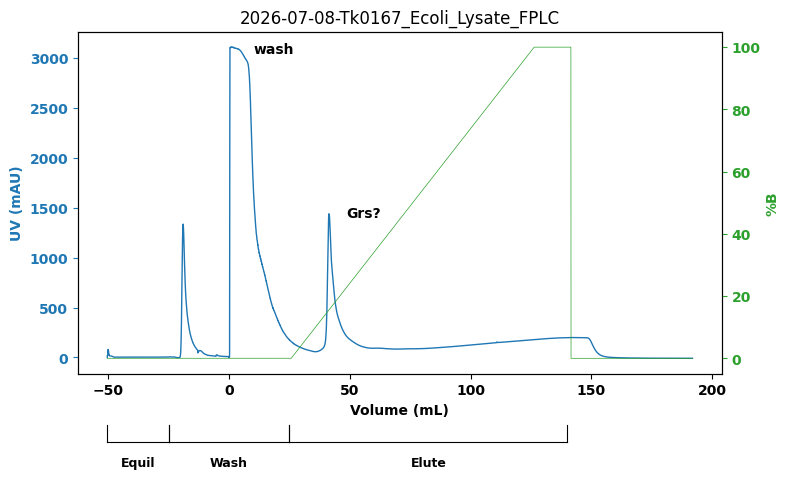

In [137]:
# set x and y 
x_uv_cond = uv_cond_df["ml"]
x_gradient = concB_df["ml.2"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"]
y_gradient = concB_df["%B"]

fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))

# set axes 
ax1.set_xlabel("Volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)

# plot uv
ax1.plot(x_uv_cond, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

# plot conductance 
if show_cond:
    ax2 = ax1.twinx()
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x_uv_cond, y_cond, color=color_cond, linewidth=0.5, linestyle="-")
    ax2.tick_params(axis="y", colors=color_cond)

if show_gradient:
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.15 if show_cond else 1.0))  # offset the third y-axis if cond is also plotted
    ax3.set_ylabel("%B", color=color_gradient)
    ax3.plot(x_gradient, y_gradient, color=color_gradient, linewidth=0.5, linestyle="-")
    ax3.tick_params(axis="y", colors=color_gradient)

if show_peak_labels:
    tol = 0.5  # simple tolerance in mL for matching peak locations
    for peak in peak_labels.values():
        target_ml = peak["ml"]
        match_idx = None

        if find_peak_max:
            # find the nearest local maximum near the requested mL
            target_idx = None
            min_diff = None
            for i, x in enumerate(x_uv_cond):
                diff = abs(float(x) - target_ml)
                if diff < tol and (min_diff is None or diff < min_diff):
                    min_diff = diff
                    target_idx = i

            if target_idx is None:
                continue

            # search a small neighborhood around target_idx for the local maximum
            search_range = 1000
            start = max(0, target_idx - search_range)
            end = min(len(y_uv) - 1, target_idx + search_range)
            local_slice = y_uv.iloc[start:end + 1]
            peak_idx = local_slice.idxmax()
            match_idx = int(peak_idx)
        else:
            # use the exact requested mL input
            for i, x in enumerate(x_uv_cond):
                if abs(float(x) - target_ml) < tol:
                    match_idx = i
                    break

        if match_idx is None:
            continue

        x_peak = x_uv_cond.iloc[match_idx]
        y_peak = y_uv.iloc[match_idx]

        label_x = x_peak + peak_label_offset * x_uv_cond.max()
        label_y = y_peak

        ax1.annotate(
            peak["label"],
            xy=(x_peak, y_peak),
            xytext=(label_x, label_y),
            textcoords="data",
            ha="center",
            va="center",
            fontsize=10
        )

if show_step_labels:
    start_ml = x_uv_cond.min()  # Initialize start_ml to the minimum x value
    step_label_offset = -0.03 * fig_height  # offset for step labels as fraction of total height
    step_label_bottom_bracket = step_label_offset - 0.01 * fig_height  # offset for bottom bracket of step labels
    for step in step_labels.values():
        end_ml = step["end_ml"]
        label = step["label"]

        start_x = x_uv_cond.iloc[(x_uv_cond - start_ml).abs().idxmin()]
        end_x = x_uv_cond.iloc[(x_uv_cond - end_ml).abs().idxmin()]

        # draw a bracket-like span below the axis
        ax1.plot(
            [start_x, start_x],
            [step_label_offset, step_label_bottom_bracket],
            transform=ax1.get_xaxis_transform(),
            color="black",
            lw=0.8,
            clip_on=False,
        )
        ax1.plot(
            [end_x, end_x],
            [step_label_offset, step_label_bottom_bracket],
            transform=ax1.get_xaxis_transform(),
            color="black",
            lw=0.8,
            clip_on=False,
        )
        ax1.plot(
            [start_x, end_x],
            [step_label_bottom_bracket, step_label_bottom_bracket],
            transform=ax1.get_xaxis_transform(),
            color="black",
            lw=0.8,
            clip_on=False,
        )

        ax1.text(
            (start_x + end_x) / 2,
            step_label_bottom_bracket - 0.04,
            label,
            transform=ax1.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            color="black",
            clip_on=False,
        )
        start_ml = end_ml  # Update start_ml for the next step


# show plot 
# title should match csv file for consistency 
plt.title(plot_title)

# ax1.grid(True, axis="x", alpha=0.3)  # gridlines 
fig.tight_layout()

# save png file, png name matches csv and title 
out_png = DATA_DIR / f"{plot_title}"
fig.savefig(out_png, dpi=1500)

plt.show()

## zoomed plot variable selection

In [141]:
## set variables 
plot_title = f"{csvfile[:-4]}_FPLC_zoomed"  # title for plot, remove .csv from filename

# plot axes bounds 
ml_start = -10  # AKTA labels sample injection as 0 mL, ml_start can be negative 
ml_end = 75  # recommend <90 mL window if displaying fractions for fig_width 6 
mAU_height = 1750

# choose what to show 
show_cond = 0  # show conductance data 
show_gradient = 1  # show %B
show_peak_labels = 1  # show peak labels (defined below)
show_step_labels = 1  # show step labels (defined below) 
show_frac_lines = 1  # show fractionation divisions 
show_frac_highlights = 1  # show which fractions were collected 
show_gel = 1  # show gel samples

# label peaks offset to the right
find_peak_max = 1  # 1 for find nearest max, 0 for exact mL input 
peak_labels = {
    1: {"ml": 10, "label": "wash"},
    2: {"ml": 45, "label": "Grs?"},
}
peak_label_offset = 0.075  # offset for peak labels as fraction of total width, negative for offset left 

# label FPLC block steps below the graph 
step_labels = {
    1: {"end_ml": -25, "label": "Equil"},
    2: {"end_ml": 25, "label": "Wash"},
    3: {"end_ml": 140, "label": "Elute"},
}

# todo highlight multiple groups of fractions
frac_first = 16
frac_last = 23

# add gel sample fractions in list format 
gel_samples = [9]  # list of fractions as gel samples 

# change colors 
color_uv = "tab:blue"
color_cond = "tab:orange"
color_gradient = "tab:green"
color_frac = "tab:green"
color_gel = "xkcd:mustard yellow"

# figure size 
fig_width = 12 * 0.5  # recommend roughly 12x10 * 0.5 for slides 
fig_height = 10 * 0.5 

## zoomed plot plotting

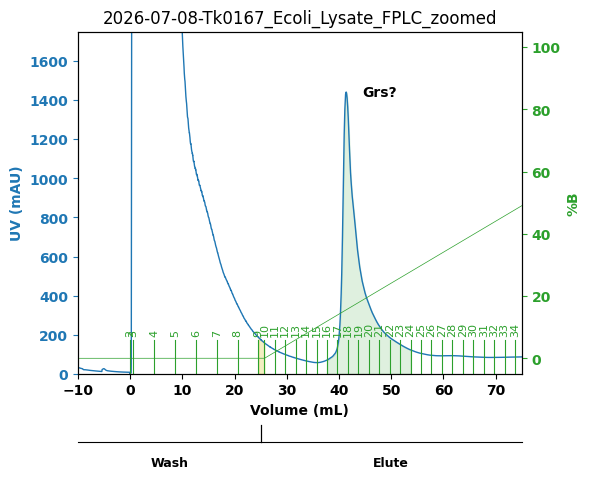

In [142]:
## plot

# set x and y 
x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

# make plot 
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))

# set axes 
ax1.set_xlabel("Volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)
ax1.set_xlim(ml_start, ml_end)
ax1.set_ylim(0, mAU_height)

# plot uv
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

# plot conductance 
if show_cond:
    ax2 = ax1.twinx()
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=0.5, linestyle="-")
    ax2.tick_params(axis="y", colors=color_cond)

# plot %B gradient
if show_gradient:
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.15 if show_cond else 1.0))  # offset the third y-axis if cond is also plotted
    ax3.set_ylabel("%B", color=color_gradient)
    ax3.plot(x_gradient, y_gradient, color=color_gradient, linewidth=0.5, linestyle="-")
    ax3.tick_params(axis="y", colors=color_gradient)

# display peak labels 
if show_peak_labels:
    tol = 0.5  # simple tolerance in mL for matching peak locations
    for peak in peak_labels.values():
        target_ml = peak["ml"]
        match_idx = None

        if find_peak_max:
            # find the nearest local maximum near the requested mL
            target_idx = None
            min_diff = None
            for i, x_enum in enumerate(x_uv_cond):
                diff = abs(float(x_enum) - target_ml)
                if diff < tol and (min_diff is None or diff < min_diff):
                    min_diff = diff
                    target_idx = i

            if target_idx is None:
                continue

            # search a small neighborhood around target_idx for the local maximum
            search_range = 1000
            start = max(0, target_idx - search_range)
            end = min(len(y_uv) - 1, target_idx + search_range)
            local_slice = y_uv.iloc[start:end + 1]
            peak_idx = local_slice.idxmax()
            match_idx = int(peak_idx)
        else:
            # use the exact requested mL input
            for i, x in enumerate(x_uv_cond):
                if abs(float(x) - target_ml) < tol:
                    match_idx = i
                    break

        if match_idx is None:
            continue

        x_peak = x_uv_cond.iloc[match_idx]
        y_peak = y_uv.iloc[match_idx]

        label_x = x_peak + peak_label_offset * (ml_end - ml_start)
        label_y = y_peak

        ax1.annotate(
            peak["label"],
            xy=(x_peak, y_peak),
            xytext=(label_x, label_y),
            textcoords="data",
            ha="center",
            va="center",
            fontsize=10
        )

# display step labels 
if show_step_labels:
    start_ml = x_uv_cond.min()  # Initialize start_ml to the minimum x value
    step_label_offset = -0.03 * fig_height  # offset for step labels as fraction of total height
    step_label_bottom_bracket = step_label_offset - 0.01 * fig_height  # offset for bottom bracket of step labels
    for step in step_labels.values():
        end_ml = step["end_ml"]
        label = step["label"]

        start_x = x_uv_cond.iloc[(x_uv_cond - start_ml).abs().idxmin()]
        end_x = x_uv_cond.iloc[(x_uv_cond - end_ml).abs().idxmin()]

        # draw a bracket-like span below the axis
        # start bracket 
        if start_ml > ml_start and start_ml < ml_end:
            ax1.plot(
                [start_x, start_x],
                [step_label_offset, step_label_bottom_bracket],
                transform=ax1.get_xaxis_transform(),
                color="black",
                lw=0.8,
                clip_on=False,
            )
        # end bracket
        if end_ml < ml_end and end_ml > ml_start:
            ax1.plot(
                [end_x, end_x],
                [step_label_offset, step_label_bottom_bracket],
                transform=ax1.get_xaxis_transform(),
                color="black",
                lw=0.8,
                clip_on=False,
            )
        # line connecting start and end brackets
        if max(start_x, ml_start) < min(end_x, ml_end):
            ax1.plot(
                [max(start_x, ml_start), min(end_x, ml_end)],
                [step_label_bottom_bracket, step_label_bottom_bracket],
                transform=ax1.get_xaxis_transform(),
                color="black",
                lw=0.8,
                clip_on=False,
            )
        if max(start_x, ml_start) < min(end_x, ml_end):
            ax1.text(
                (max(start_x, ml_start) + min(end_x, ml_end)) / 2,
                step_label_bottom_bracket - 0.04,
                label,
                transform=ax1.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=9,
                color="black",
                clip_on=False,
            )
        start_ml = end_ml  # Update start_ml for the next step

# plot fractions 
if show_frac_lines:
    # plot fraction lines and text labels 
    frac_col = "ml.5" if is_method_run else "ml.4"
    for i, (ml, frac) in enumerate(zip(fractions_df[frac_col], fractions_df["Fraction"]), start=1):
        if ml > ml_start and ml < ml_end:
            ax1.axvline(x=ml, color=color_frac, linestyle="-", linewidth=0.8, ymin=0, ymax=0.1)
            ax1.text(ml, ax1.get_ylim()[1]*0.11, f"{frac:.0f}", rotation=90,
                    va="bottom", ha="center", fontsize=8, color=color_frac, fontweight='normal')

    # shade the selected fraction range (frac_first...frac_last) under UV curve
    if show_frac_highlights:
        x_min = fractions_df.loc[fractions_df["Fraction"] == frac_first, frac_col].iloc[0]
        x_max = fractions_df.loc[fractions_df["Fraction"] == frac_last+1, frac_col].iloc[0]
        mask = (x >= x_min) & (x <= x_max)
        ax1.fill_between(x[mask], y_uv[mask], color=color_frac, alpha=0.15)

# plot gel samples 
if show_gel and len(gel_samples)>0:
    for gel_frac in gel_samples:
        x_min = fractions_df.loc[fractions_df["Fraction"] == gel_frac, frac_col].iloc[0]
        x_max = fractions_df.loc[fractions_df["Fraction"] == gel_frac+1, frac_col].iloc[0]
        mask = (x >= x_min) & (x <= x_max)
        ax1.fill_between(x[mask], y_uv[mask], color=color_gel, alpha=0.25)

# show plot 
# title should match csv file for consistency 
plt.title(plot_title)

# ax1.grid(True, axis="x", alpha=0.3) # gridlines 
fig.tight_layout()

# save png file, png name matches csv and title 
out_png = DATA_DIR / f"{plot_title}"
fig.savefig(out_png, dpi=1500)

plt.show()